# Exploratory Data Analysis (EDA) for Fact-Check Datasets

## Victoria Knapp Perez, Jason LaRuez
Original data sources:
- Politifact: https://www.kaggle.com/datasets/rmisra/politifact-fact-check-dataset/data
- WELFake: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification

---
## Importing Necessary Packages

In [1]:
# Importing data
import kagglehub
import os
import json

import matplotlib.pyplot as plt # Plotting
import pandas as pd # Pandas dataframes

from collections import Counter # For counting word occurrences
import string # string processing and tokenization
import random

---
# Dataset 1: Politifact
## Loading in dataset
### (The data consists of 8 json files containing 21,152 entries which we load into a pandas dataframe of size (21152,8) )

In [2]:
# Download latest version of data
path = kagglehub.dataset_download("rmisra/politifact-fact-check-dataset")

print("Path to dataset files:", path)

# List all files in the downloaded dataset directory
files = os.listdir(path)

# Load the data
json_files = [f for f in files if f.endswith('.json')]

# Load the first JSON file found
data_file = os.path.join(path, json_files[0])

# Read the JSON file
# This joins the multiple json files into a single dataframe
df = pd.read_json(data_file, lines=True)

print(f"\nLoaded file: {json_files[0]}")
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

100%|██████████| 2.29M/2.29M [00:00<00:00, 3.73MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rmisra/politifact-fact-check-dataset/versions/1

Loaded file: politifact_factcheck_data.json
Dataset shape: (21152, 8)

First few rows:
       verdict statement_originator  \
0         true         Barack Obama   
1        false           Matt Gaetz   
2  mostly-true         Kelly Ayotte   
3        false             Bloggers   
4    half-true         Bobby Jindal   

                                           statement statement_date  \
0  John McCain opposed bankruptcy protections for...      6/11/2008   
1  "Bennie Thompson actively cheer-led riots in t...       6/7/2022   
2  Says Maggie Hassan was "out of state on 30 day...      5/18/2016   
3  "BUSTED: CDC Inflated COVID Numbers, Accused o...       2/1/2021   
4  "I'm the only (Republican) candidate that has ...      8/30/2015   

  statement_source        factchecker factcheck_date  \
0           speech  Adriel Bettelheim      6/16/2008   
1       television        Yacob Rey

Our objective is to use the text in the 'statement' column to predict the politifact 'verdict'. According to Politifact's "truth-o-meter" methodology page, these verdicts are:
1. true: The statement is accurate and there's nothing significant missing.
2. mostly-true: The statement is accurate but needs clarification or additional information.
3. half-true: The statement is partially accurate but leaves out important details and takes things out of context.
4. mostly-false: The statement contains and element of truth but ignores critical facts that would give a different impression.
5. false: The statement is not accurate.
6. pants-fire: The statement is not accurate and makes a ridiculous claim. a.k.a. "Liar, Liar, Pants on Fire!"

---
First we look at the distribution of fact-check verdicts, finding "false" to be the most frequent verdict with 5625 occurrences.

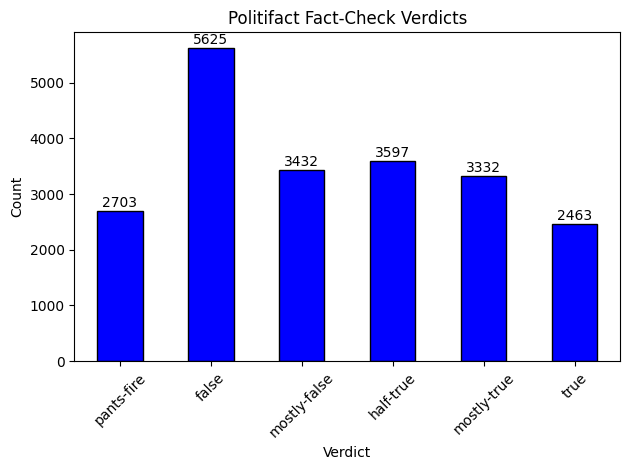

In [3]:
# Define the verdict ordering
verdict_order = ['pants-fire', 'false', 'mostly-false', 'half-true', 'mostly-true', 'true']

# Reindex the data to apply the order for plot
verdict_distribution = df['verdict'].value_counts()
verdict_distribution_ordered = verdict_distribution.reindex(verdict_order)

ax = verdict_distribution_ordered.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Politifact Fact-Check Verdicts')
plt.xlabel('Verdict')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='center')

# Add frequency counts above the bars
for i, v in enumerate(verdict_distribution_ordered):
    ax.text(i, v + 20, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

It may be interesting to know the breakdown of each statement sources for each of these verdicts. First, we sort the statement sources by their total number of occurrences. Then, for each verdict, we construct a stacked bar showing the distribution of statement sources with the most frequently occurring statement sources at the top. We see that an exceptionally large proportion of statements labelled false come from social media. This is interesting when we group these labels into True vs False. pants-fire + false + mostly-false accounts for slightly more of the data than half-true + most-true + true.

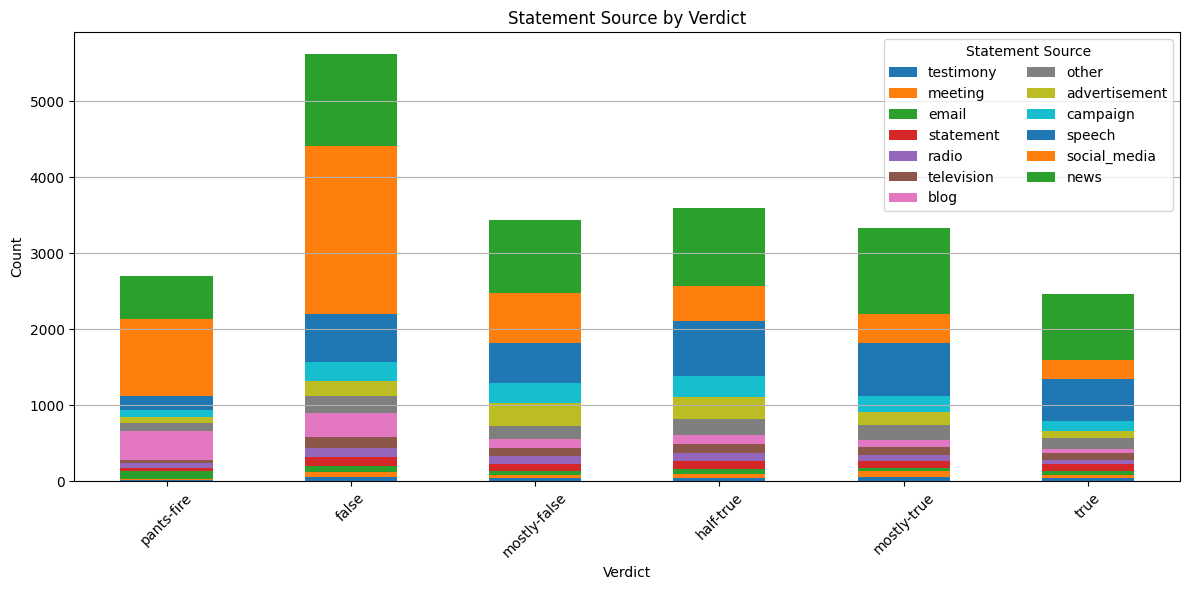

In [4]:
# Create dataframe where each entry is the number of occurrences for a given verdict (row) and statement_source (column)
source_by_verdict = df.groupby(['verdict', 'statement_source']).size().unstack(fill_value=0)

# Reindex the DataFrame to apply the desired order for rows (verdicts)
source_by_verdict_ordered = source_by_verdict.reindex(verdict_order)

# Calculate the overall frequency of each statement source
statement_source_totals = df['statement_source'].value_counts()

# Get the order of statement sources based on overall frequency (least frequent to most frequent for stacking bottom-up)
source_order_for_stacking = statement_source_totals.sort_values(ascending=True).index

# Reindex the columns (statement sources) of the DataFrame based on the desired stacking order
source_by_verdict_reordered_for_stacking = source_by_verdict_ordered[source_order_for_stacking]

source_by_verdict_reordered_for_stacking.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Statement Source by Verdict')
plt.xlabel('Verdict')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='center')
plt.grid(axis='y')
plt.legend(title='Statement Source', ncol = 2)
plt.tight_layout()
plt.show()

Next we look at the distribution of verdicts as a function of the year the statement was made. We see that in 2000 and 2002 there are singular politifact checks that seem out of place in the data set. We also see that in 2007-2009 there are fewer fact checks, increasing significantly in 2010 and maintaining a relatively consistent pattern of activity  through 2021. There is a dip in 2022, perhaps the data was constructed partway through 2022. The lower activity in 2007-2009 corresponds to polifact first launching in 2007, then receiving a pulitzer prize in 2009. It then received a surge in support and funding explaining the increase in activity

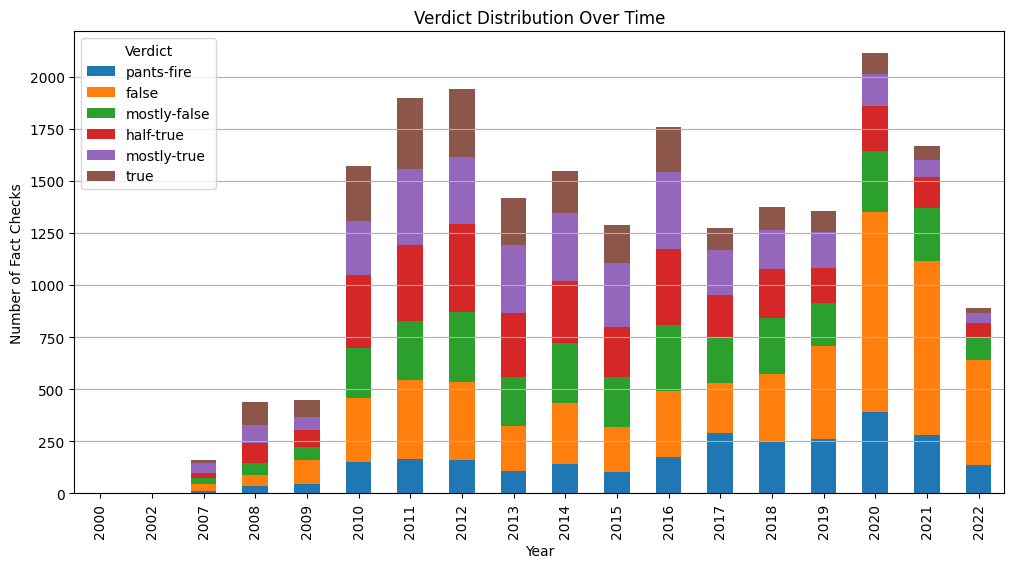

In [5]:
df['statement_date'] = pd.to_datetime(df['statement_date'], errors='coerce')
df['year'] = df['statement_date'].dt.year

verdict_trend_by_year = df.groupby(['year', 'verdict']).size().unstack(fill_value=0)

# Reindex the DataFrame to apply the desired order for columns (verdicts)
verdict_trend_by_year_ordered = verdict_trend_by_year[verdict_order]

verdict_trend_by_year_ordered.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Verdict Distribution Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Fact Checks')
plt.grid(axis='y')
plt.legend(title='Verdict')
plt.show()

In [6]:
# Filter the DataFrame for entries with the year 2000 or 2002
filtered_statements = df[df['year'].isin([2000, 2002])]['statement']

# Print the filtered statements
for statement in filtered_statements:
    print(statement)

The economic impact of Atlanta's 2000 Super Bowl was $292 million.
"Financed the largest parking expansion program without a rate increase."


Here we look at the distribution of sources from which statements were made, and within each distribution we look at the distribution of verdict classes for the given statement sources. Clearly news, social media and speech are the 3 most frequent statement sources.

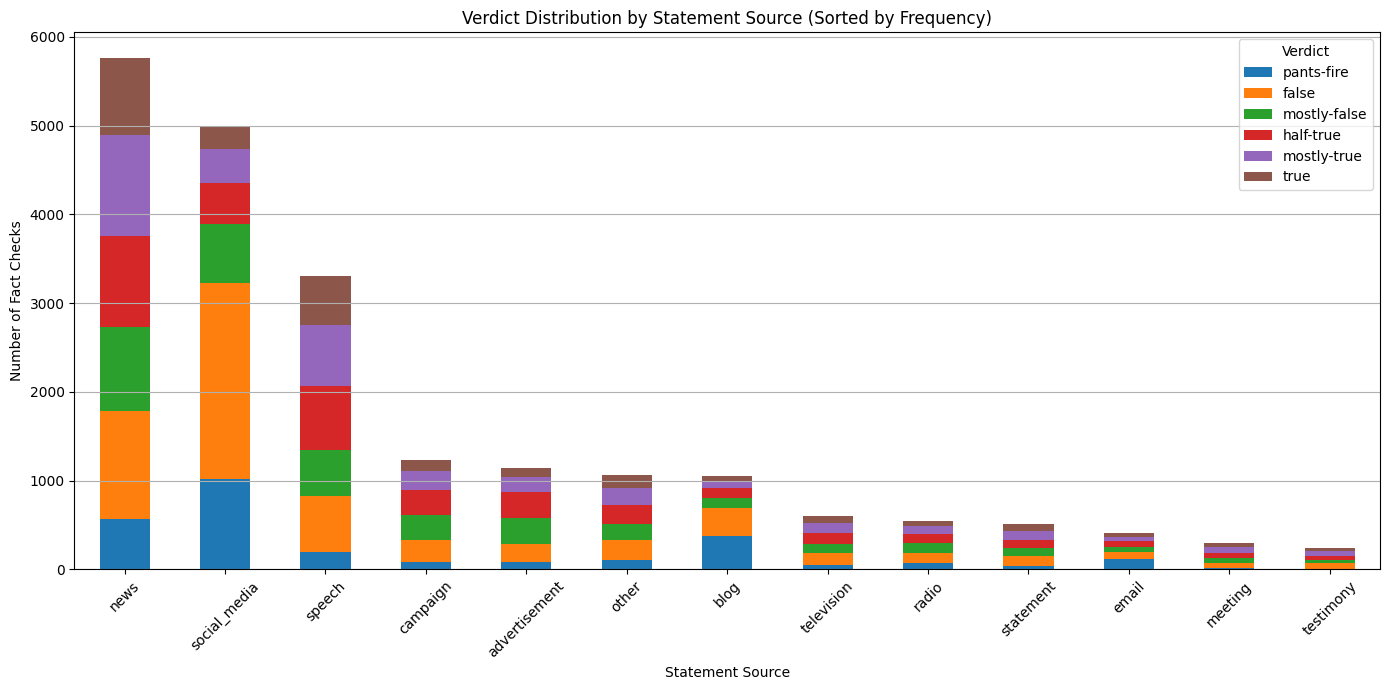

In [7]:
statement_source_distribution = df['statement_source'].value_counts()

verdict_by_source = df.groupby(['statement_source', 'verdict']).size().unstack(fill_value=0)

# Reindex the DataFrame to apply the desired order for columns (verdicts) for stacking
verdict_by_source_ordered = verdict_by_source[verdict_order]

# Calculate the total frequency for each statement source and sort in descending order
verdict_by_source_sorted = verdict_by_source_ordered.sum(axis=1).sort_values(ascending=False)

# Reindex the ordered DataFrame based on the sorted total frequencies
verdict_by_source_ordered = verdict_by_source_ordered.reindex(verdict_by_source_sorted.index)

verdict_by_source_ordered.plot(kind='bar', stacked=True, figsize=(14, 7))
plt.title('Verdict Distribution by Statement Source (Sorted by Frequency)')
plt.xlabel('Statement Source')
plt.ylabel('Number of Fact Checks')
plt.xticks(rotation=45, ha='center')
plt.grid(axis='y')
plt.legend(title='Verdict')
plt.tight_layout()
plt.show()

---
Next, we will look at the lengths of the statements/texts to see if there are different lengths distributions for different statement_sources and/or verdicts.

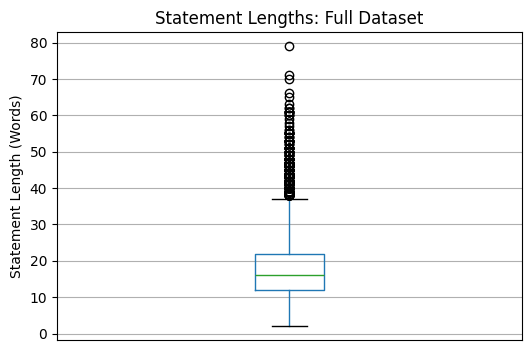

In [8]:
def clean_and_tokenize(text):
    """Removes punctuation, converts to lowercase, and tokenizes text."""
    if isinstance(text, str):
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = text.lower()
        return text.split()
    return [] # Return empty list for non-string inputs

df['statement_length'] = df['statement'].apply(clean_and_tokenize)
df['statement_length'] = df['statement_length'].apply(len)

plt.figure(figsize=(6, 4))
df.boxplot(column='statement_length')
plt.title('Statement Lengths: Full Dataset')
plt.xticks([])
plt.ylabel('Statement Length (Words)')
plt.show()

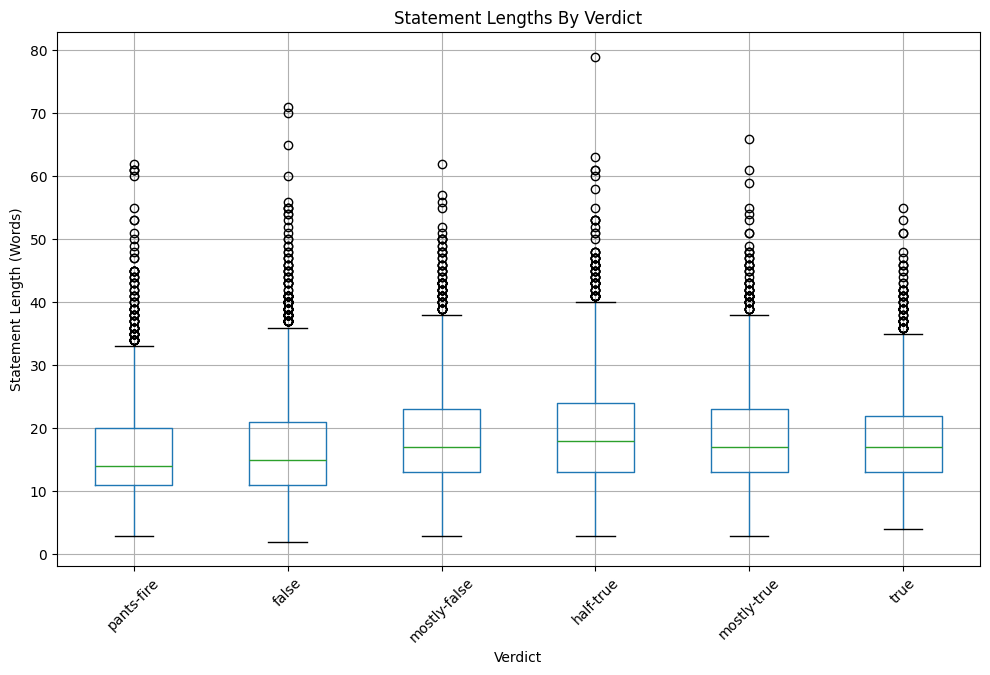

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

# Create a temporary copy of the dataframe
df_temp = df.copy()

# Convert 'verdict' to a categorical type with the desired order in the temporary dataframe
df_temp['verdict'] = pd.Categorical(df_temp['verdict'], categories=verdict_order, ordered=True)

# Plot using the temporary dataframe
df_temp.boxplot(column='statement_length', by='verdict', ax=ax)

ax.set_title('Statement Lengths By Verdict')
ax.set_xlabel('Verdict')
ax.set_ylabel('Statement Length (Words)')
plt.xticks(rotation=45, ha='center')
fig.suptitle('')
plt.tight_layout()
plt.show()

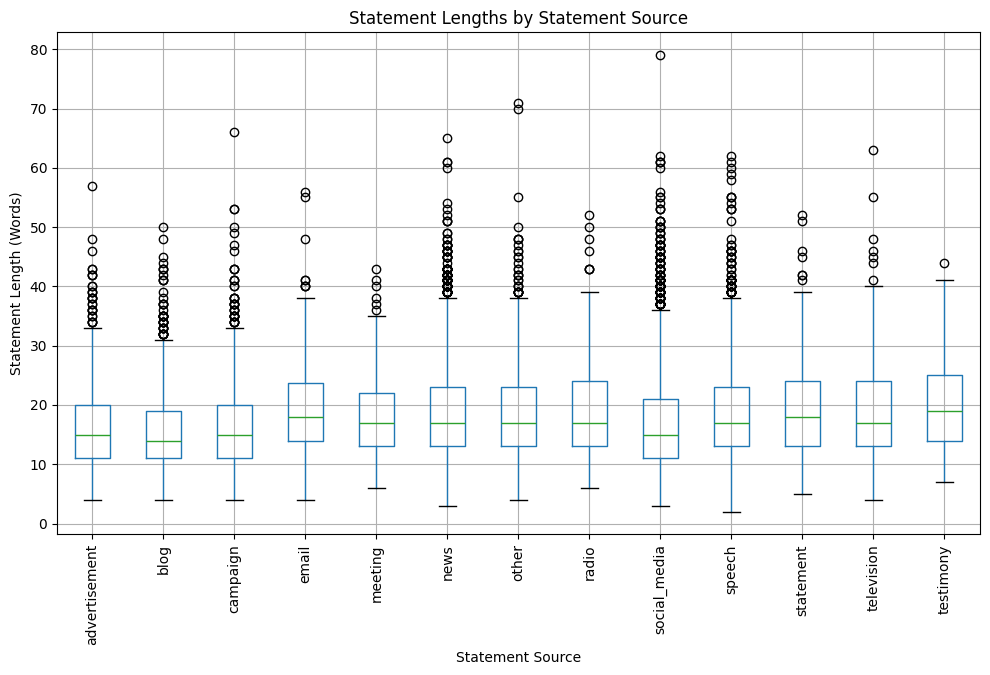

In [10]:
# Create boxplots, ordering the x-axis by the frequency of statement sources
fig, ax = plt.subplots(figsize=(10, 7))
df_temp.boxplot(column='statement_length', by='statement_source', ax=ax) # 'order' is not needed after converting to categorical
ax.set_title('Statement Lengths by Statement Source')
ax.set_xlabel('Statement Source')
ax.set_ylabel('Statement Length (Words)')
plt.xticks(rotation=90, ha='center')
fig.suptitle('')
plt.tight_layout()
plt.show()

Overall there do not appear to be big differences in the distributions of statement lengths for different verdicts and statement sources, with the average statement length being right around 100 words. Thus the statement length likely won't be useful for classification.

---
Next, we will consider the proportion of "stop words" in the texts. A stop word is a word that is not considered to have much value/meaning, such as "a", "the", "as", etc.

In [11]:
def calculate_stop_word_proportion(text):
    """Calculates the proportion of stop words in a text."""
    tokens = clean_and_tokenize(text)
    total_words = len(tokens)
    if total_words == 0:
        return 0
    stop_word_count = sum(1 for word in tokens if word in stop_words)
    return stop_word_count / total_words

# list of "stop words" from NLTK: These are words which are considered not to have much value in NLP
stop_words = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself",
              "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself",
              "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that",
              "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had",
              "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because",
              "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between", "into",
              "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out",
              "on", "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where",
              "why", "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no",
              "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just",
              "don", "should", "now"]

df['stop_word_proportion'] = df['statement'].apply(calculate_stop_word_proportion)

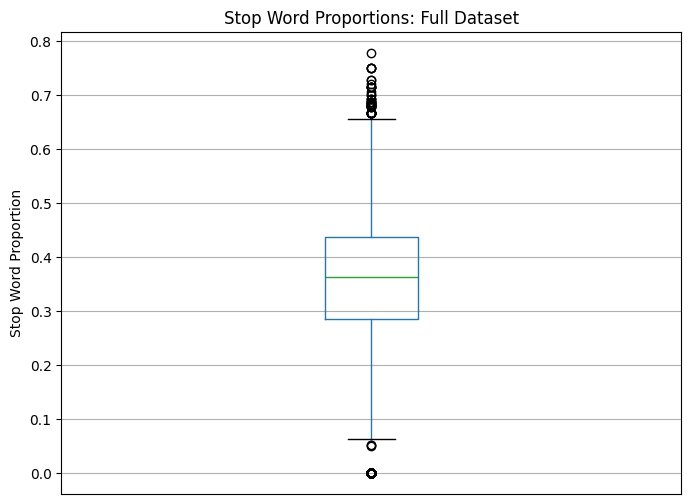

In [12]:
plt.figure(figsize=(8, 6))
df.boxplot(column='stop_word_proportion')
plt.title('Stop Word Proportions: Full Dataset')
plt.xticks([])
plt.ylabel('Stop Word Proportion')
plt.show()

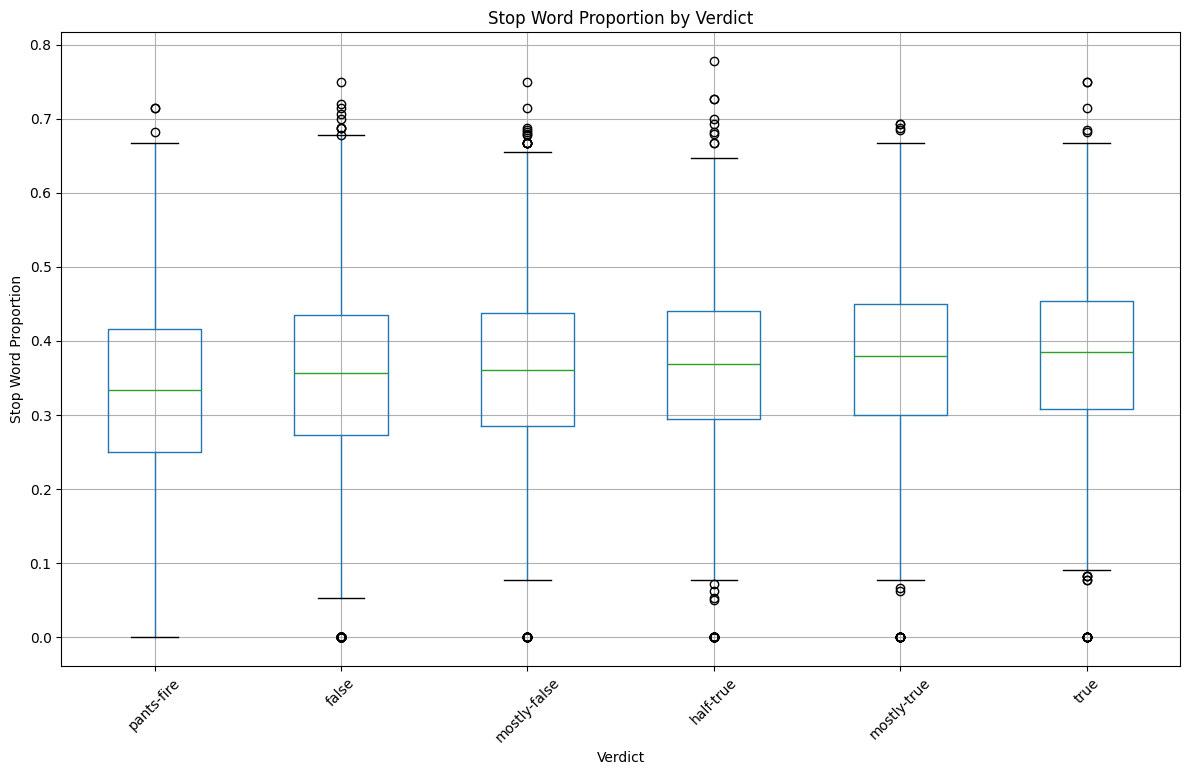

In [13]:
# Create a temporary copy of the dataframe
df_temp = df.copy()

# Convert 'verdict' to a categorical type with the desired order in the temporary dataframe
df_temp['verdict'] = pd.Categorical(df_temp['verdict'], categories=verdict_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 8))
df_temp.boxplot(column='stop_word_proportion', by='verdict', ax=ax)
ax.set_title('Stop Word Proportion by Verdict')
ax.set_xlabel('Verdict')
ax.set_ylabel('Stop Word Proportion')
plt.xticks(rotation=45, ha='center')
fig.suptitle('')
plt.tight_layout()
plt.show()

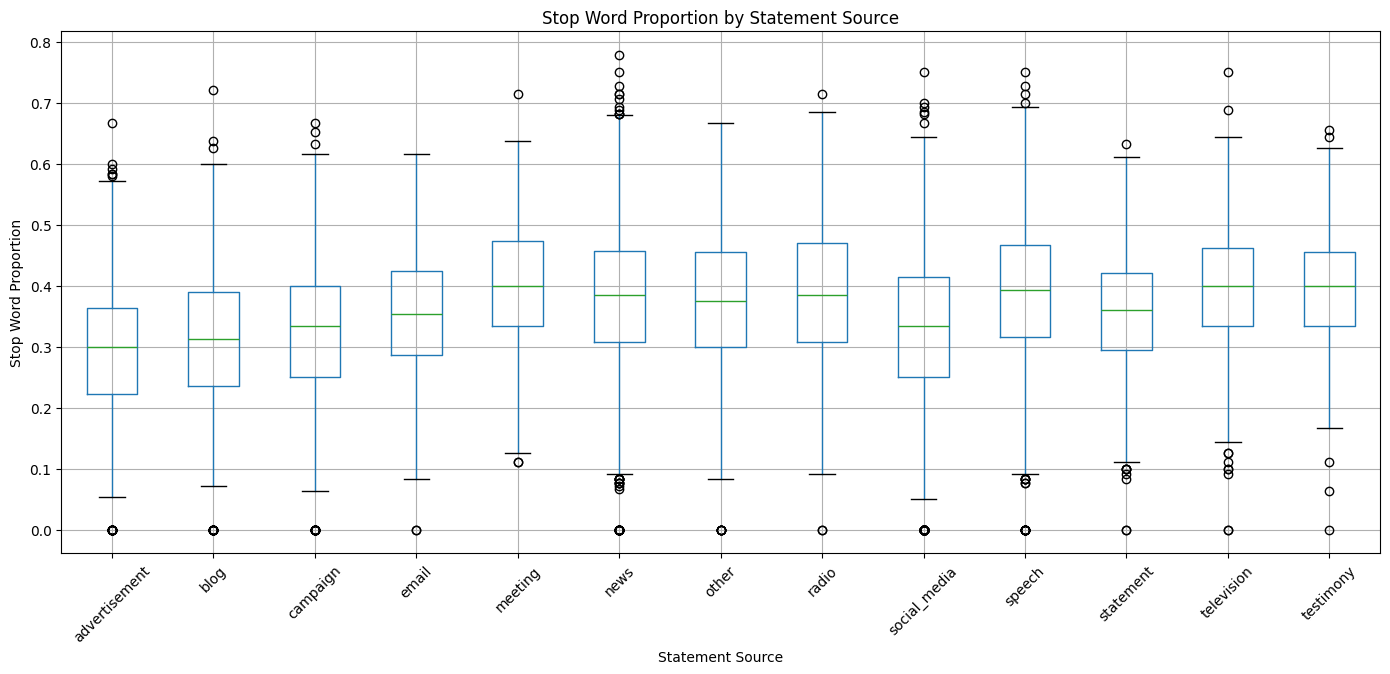

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
df.boxplot(column='stop_word_proportion', by='statement_source', ax=ax)
ax.set_title('Stop Word Proportion by Statement Source')
ax.set_xlabel('Statement Source')
ax.set_ylabel('Stop Word Proportion')
plt.xticks(rotation=45, ha='center')
fig.suptitle('')
plt.tight_layout()
plt.show()

Similarly to the text lengths, the stop word proportion distributions are quite similar for each verdict and statement source, with quite a wide range of proportions across the board. As a result, we do not expect stop word proportion to be useful for classification.

---

Now we will look at frequency of words and n-grams. An n-gram is a sequence of n-many consecutive words that appears frequently. For example "united" may not occur unusually frequently by itself, the but the 2-gram "united states" likely occurs far more often than many other 2-grams. We first remove stop words to avoid words that occur with obviously high frequency.

In [15]:
word_frequencies_per_statement_by_verdict = {}

df_by_verdict = {}

for verdict in verdict_order:
    df_by_verdict[verdict] = df[df['verdict'] == verdict].copy()

for verdict, df_subset in df_by_verdict.items():
    # Apply the clean_and_tokenize function to the 'statement' column
    tokenized_statements = df_subset['statement'].apply(clean_and_tokenize)

    # Flatten the list of lists into a single list of words
    all_words = [word for tokens in tokenized_statements for word in tokens if word not in stop_words]

    # Calculate word frequencies
    word_frequencies = Counter(all_words)

    # Calculate frequency per statement
    num_statements = df_subset.shape[0]
    word_frequencies_per_statement = {word: int(freq) for word, freq in word_frequencies.items()}

    word_frequencies_per_statement_by_verdict[verdict] = word_frequencies_per_statement

# Display the number of unique words found for each verdict
for verdict, frequencies in word_frequencies_per_statement_by_verdict.items():
    print(f"Verdict '{verdict}': {len(frequencies)} unique words")

Verdict 'pants-fire': 7672 unique words
Verdict 'false': 11337 unique words
Verdict 'mostly-false': 8356 unique words
Verdict 'half-true': 8215 unique words
Verdict 'mostly-true': 7456 unique words
Verdict 'true': 6294 unique words


In [16]:
# Define how many of the most frequent words to display
top_n = 10

for verdict, frequencies in word_frequencies_per_statement_by_verdict.items():
    print(f"\nTop {top_n} most frequent words for verdict '{verdict}':")
    # Since 'frequencies' is now a dictionary, convert it to a Counter for most_common()
    word_frequencies_counter = Counter(frequencies)
    for word, frequency in word_frequencies_counter.most_common(top_n):
        print(f"- {word}: {frequency}") # Format to 4 decimal places for readability


Top 10 most frequent words for verdict 'pants-fire':
- says: 822
- president: 223
- trump: 222
- obama: 215
- said: 174
- people: 150
- us: 136
- shows: 125
- barack: 112
- donald: 111

Top 10 most frequent words for verdict 'false':
- says: 1485
- people: 385
- president: 361
- us: 281
- shows: 279
- state: 277
- trump: 270
- said: 260
- obama: 242
- percent: 238

Top 10 most frequent words for verdict 'mostly-false':
- says: 919
- percent: 249
- people: 231
- tax: 226
- president: 223
- obama: 207
- state: 205
- health: 200
- us: 193
- care: 177

Top 10 most frequent words for verdict 'half-true':
- says: 897
- percent: 440
- people: 274
- state: 273
- tax: 249
- million: 234
- jobs: 215
- years: 210
- would: 208
- health: 205

Top 10 most frequent words for verdict 'mostly-true':
- says: 681
- percent: 480
- state: 280
- people: 238
- years: 231
- year: 228
- tax: 222
- million: 215
- states: 195
- new: 168

Top 10 most frequent words for verdict 'true':
- says: 465
- percent: 321


In [17]:
def generate_ngrams(tokens, n):
    """Generates n-grams from a list of tokens."""
    ngrams = []
    for i in range(len(tokens) - n + 1):
        ngrams.append(tuple(tokens[i:i+n]))
    return ngrams

# Apply the clean_and_tokenize function to the 'statement' column for the entire dataframe
tokenized_statements_all = df['statement'].apply(clean_and_tokenize)

# Flatten the list of lists into a single list of words, excluding stop words
all_words_cleaned = [word for tokens in tokenized_statements_all for word in tokens if word not in stop_words]

# Generate bigrams and trigrams
bigrams_all = generate_ngrams(all_words_cleaned, 2)
trigrams_all = generate_ngrams(all_words_cleaned, 3)

# Count the occurrences of each bigram and trigram
bigram_counts_all = Counter(bigrams_all)
trigram_counts_all = Counter(trigrams_all)

# Display the number of unique bigrams and trigrams found
print(f"Number of unique bigrams in the entire dataset: {len(bigram_counts_all)}")
print(f"Number of unique trigrams in the entire dataset: {len(trigram_counts_all)}")

Number of unique bigrams in the entire dataset: 167281
Number of unique trigrams in the entire dataset: 221095


In [18]:
bigram_counts_by_verdict = {}
trigram_counts_by_verdict = {}

for verdict in verdict_order:
    df_subset = df_by_verdict[verdict]

    # Apply the clean_and_tokenize function to the 'statement' column
    tokenized_statements = df_subset['statement'].apply(clean_and_tokenize)

    # Flatten the list of lists into a single list of words, excluding stop words
    all_words = [word for tokens in tokenized_statements for word in tokens if word not in stop_words]

    # Generate bigrams and trigrams
    bigrams = generate_ngrams(all_words, 2)
    trigrams = generate_ngrams(all_words, 3)

    # Count the occurrences of each bigram and trigram
    bigram_counts_by_verdict[verdict] = Counter(bigrams)
    trigram_counts_by_verdict[verdict] = Counter(trigrams)

    # Print the number of unique bigrams and trigrams found for each verdict
    print(f"Verdict '{verdict}': {len(bigram_counts_by_verdict[verdict])} unique bigrams, {len(trigram_counts_by_verdict[verdict])} unique trigrams")

Verdict 'pants-fire': 24165 unique bigrams, 27242 unique trigrams
Verdict 'false': 49285 unique bigrams, 57708 unique trigrams
Verdict 'mostly-false': 33249 unique bigrams, 38608 unique trigrams
Verdict 'half-true': 34978 unique bigrams, 41586 unique trigrams
Verdict 'mostly-true': 31176 unique bigrams, 36922 unique trigrams
Verdict 'true': 22833 unique bigrams, 26294 unique trigrams


In [19]:
bigram_counts_by_source = {}
trigram_counts_by_source = {}

unique_sources = df['statement_source'].unique()

for source in unique_sources:
    df_subset = df[df['statement_source'] == source].copy()

    tokenized_statements = df_subset['statement'].apply(clean_and_tokenize)

    all_words = [word for tokens in tokenized_statements for word in tokens if word not in stop_words]

    bigrams = generate_ngrams(all_words, 2)
    trigrams = generate_ngrams(all_words, 3)

    bigram_counts_by_source[source] = Counter(bigrams)
    trigram_counts_by_source[source] = Counter(trigrams)

    print(f"Statement Source '{source}': {len(bigram_counts_by_source[source])} unique bigrams, {len(trigram_counts_by_source[source])} unique trigrams")

Statement Source 'speech': 29336 unique bigrams, 34983 unique trigrams
Statement Source 'television': 6153 unique bigrams, 6647 unique trigrams
Statement Source 'news': 52011 unique bigrams, 62944 unique trigrams
Statement Source 'blog': 10284 unique bigrams, 10950 unique trigrams
Statement Source 'other': 10916 unique bigrams, 11823 unique trigrams
Statement Source 'social_media': 45637 unique bigrams, 52920 unique trigrams
Statement Source 'advertisement': 10536 unique bigrams, 12180 unique trigrams
Statement Source 'campaign': 11408 unique bigrams, 13048 unique trigrams
Statement Source 'meeting': 2988 unique bigrams, 3126 unique trigrams
Statement Source 'radio': 5659 unique bigrams, 6058 unique trigrams
Statement Source 'email': 4626 unique bigrams, 4912 unique trigrams
Statement Source 'testimony': 2763 unique bigrams, 2880 unique trigrams
Statement Source 'statement': 5871 unique bigrams, 6244 unique trigrams


In [20]:
# Print top n-grams for the entire dataset
top_n_all = 20
print(f"Top {top_n_all} most frequent bigrams for the entire dataset:")
for bigram, count in bigram_counts_all.most_common(top_n_all):
    print(f"- {bigram}: {count}")

print(f"\nTop {top_n_all} most frequent trigrams for the entire dataset:")
for trigram, count in trigram_counts_all.most_common(top_n_all):
    print(f"- {trigram}: {count}")

# Print top n-grams for each verdict
top_n_verdict = 10
for verdict, bigram_counts in bigram_counts_by_verdict.items():
    print(f"\nTop {top_n_verdict} most frequent bigrams for verdict '{verdict}':")
    for bigram, count in bigram_counts.most_common(top_n_verdict):
        print(f"- {bigram}: {count}")

for verdict, trigram_counts in trigram_counts_by_verdict.items():
    print(f"\nTop {top_n_verdict} most frequent trigrams for verdict '{verdict}':")
    for trigram, count in trigram_counts.most_common(top_n_verdict):
        print(f"- {trigram}: {count}")


# Print top n-grams for each statement source
top_n_source = 10
for source, bigram_counts in bigram_counts_by_source.items():
    print(f"\nTop {top_n_source} most frequent bigrams for statement source '{source}':")
    for bigram, count in bigram_counts.most_common(top_n_source):
        print(f"- {bigram}: {count}")

for source, trigram_counts in trigram_counts_by_source.items():
    print(f"\nTop {top_n_source} most frequent trigrams for statement source '{source}':")
    for trigram, count in trigram_counts.most_common(top_n_source):
        print(f"- {trigram}: {count}")

Top 20 most frequent bigrams for the entire dataset:
- ('health', 'care'): 620
- ('united', 'states'): 516
- ('barack', 'obama'): 430
- ('donald', 'trump'): 423
- ('joe', 'biden'): 304
- ('hillary', 'clinton'): 272
- ('president', 'barack'): 240
- ('social', 'security'): 205
- ('says', 'president'): 203
- ('new', 'york'): 200
- ('photo', 'shows'): 191
- ('president', 'obama'): 177
- ('last', 'year'): 166
- ('says', 'donald'): 166
- ('health', 'insurance'): 160
- ('mitt', 'romney'): 145
- ('white', 'house'): 141
- ('scott', 'walker'): 139
- ('says', 'joe'): 136
- ('supreme', 'court'): 130

Top 20 most frequent trigrams for the entire dataset:
- ('president', 'barack', 'obama'): 183
- ('says', 'donald', 'trump'): 144
- ('says', 'joe', 'biden'): 109
- ('says', 'hillary', 'clinton'): 101
- ('says', 'president', 'barack'): 90
- ('health', 'care', 'law'): 84
- ('president', 'donald', 'trump'): 83
- ('affordable', 'care', 'act'): 67
- ('says', 'mitt', 'romney'): 63
- ('gov', 'scott', 'walker'

---
# Dataset 2: WELFake
This dataset contains a dataframe of 72134 entries with 4 columns (column "Unnamed:" is simply an index). The three columns of interest are "title", "text" and "label". We will generate the same plots and frequencies as we did for the Politifact dataset, except there are no statement sources and only two verdicts.

In [21]:
# Download latest version of data
path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")

print("Path to dataset files:", path)

# List all files in the downloaded dataset directory
files = os.listdir(path)

news_file = os.path.join(path, "WELFake_Dataset.csv")

df_news = pd.read_csv(news_file) #Load data from csv to pd

df_news.head(3)

100%|██████████| 92.1M/92.1M [00:03<00:00, 30.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/saurabhshahane/fake-news-classification/versions/77


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1


In [22]:
print("There are "+str(len(df_news))+" many data entries")

num_nan_rows = df_news.isna().any(axis=1).sum()
print("There are "+str(num_nan_rows)+" many rows with NaN entry that we disregard")

# Get all rows that contain at least one NaN
df_news_nonnan = df_news[~df_news.isna().any(axis=1)]

There are 72134 many data entries
There are 597 many rows with NaN entry that we disregard



First we look at the distribution of true (0) vs. fake (1) news

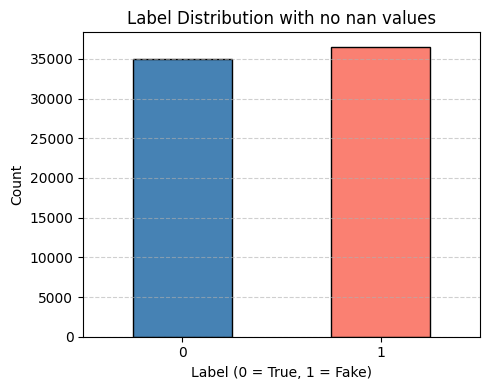

In [23]:
# Make an explicit copy first
df_news_nonnan2 = df_news_nonnan.copy()

# Then safely modify the column
df_news_nonnan2['label'] = df_news_nonnan2['label'].astype(int)

# Plot histogram / bar chart
plt.figure(figsize=(5,4))
df_news_nonnan2['label'].value_counts().sort_index().plot(
    kind='bar', color=['steelblue', 'salmon'], edgecolor='black'
)
plt.title('Label Distribution with no nan values')
plt.xlabel('Label (0 = True, 1 = Fake)')
plt.ylabel('Count')
plt.xticks([0, 1], ['0', '1'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

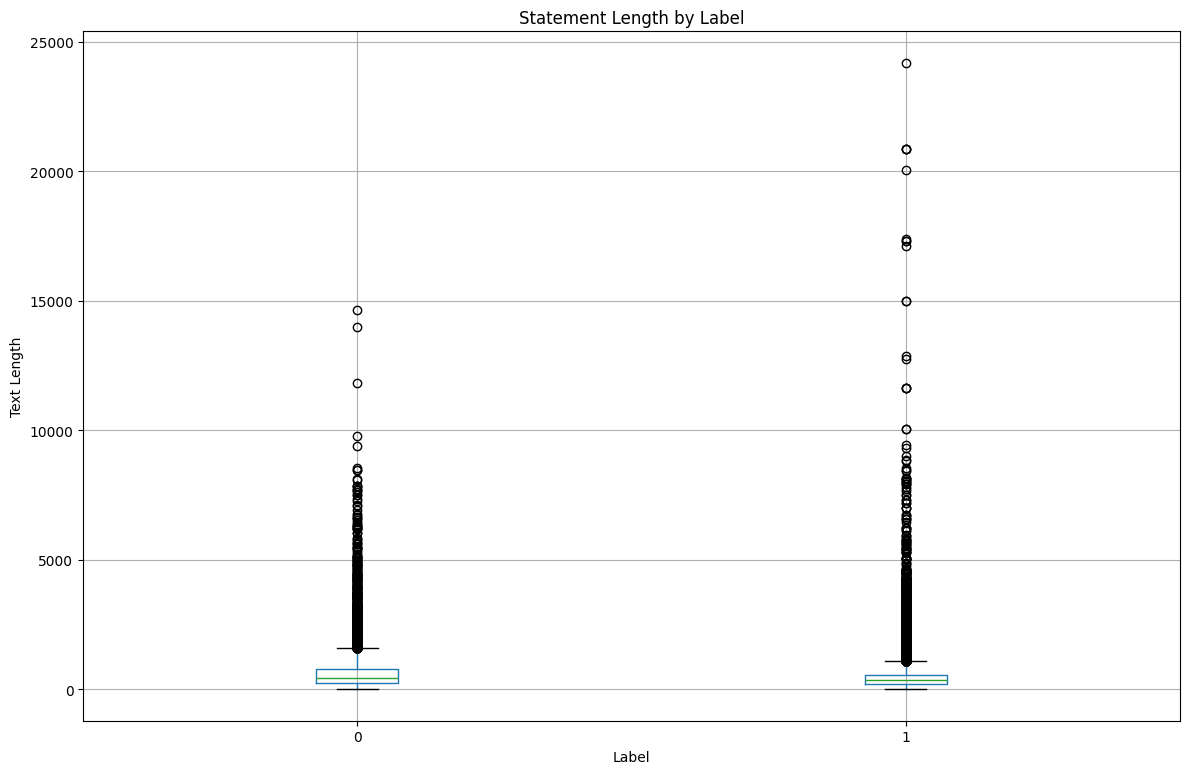

In [24]:
df_news_nonnan2['text_length'] = df_news_nonnan2['text'].apply(clean_and_tokenize)
df_news_nonnan2['text_length'] = df_news_nonnan2['text_length'].apply(len)

fig, ax = plt.subplots(figsize=(12, 8))
df_news_nonnan2.boxplot(column='text_length', by='label', ax=ax)
ax.set_title('Statement Length by Label')
ax.set_xlabel('Label')
ax.set_ylabel('Text Length')
plt.xticks(rotation=0, ha='center')
fig.suptitle('')
plt.tight_layout()
plt.show()

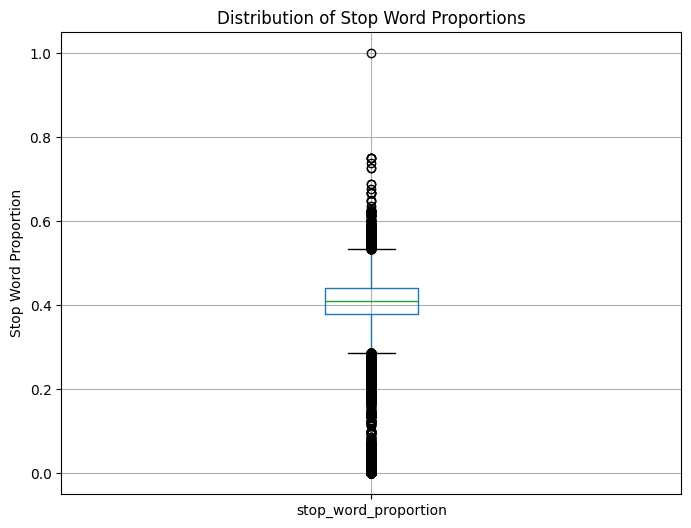

In [25]:
df_news_nonnan2['stop_word_proportion'] = df_news_nonnan2['text'].apply(calculate_stop_word_proportion)


plt.figure(figsize=(8, 6))
df_news_nonnan2.boxplot(column='stop_word_proportion')
plt.title('Distribution of Stop Word Proportions')
plt.ylabel('Stop Word Proportion')
plt.show()

In [26]:
word_frequencies_per_statement_by_label = {}

unique_labels= df_news_nonnan2['label'].unique()
df_by_label = {}

for label in unique_labels:
    df_by_label[label] = df_news_nonnan2[df_news_nonnan2['label'] == label].copy()

for label, df_subset in df_by_label.items():
    # Apply the clean_and_tokenize function to the 'statement' column
    tokenized_statements = df_subset['text'].apply(clean_and_tokenize)

    # Flatten the list of lists into a single list of words
    all_words = [word for tokens in tokenized_statements for word in tokens if word not in stop_words]

    # Calculate word frequencies
    word_frequencies = Counter(all_words)

    # Calculate frequency per statement
    num_statements = df_subset.shape[0]
    word_frequencies_per_statement = {word: int(freq) for word, freq in word_frequencies.items()}

    word_frequencies_per_statement_by_label[label] = word_frequencies_per_statement

# Display the number of unique words found for each verdict
for label, frequencies in word_frequencies_per_statement_by_label.items():
    print(f"Verdict '{label}': {len(frequencies)} unique words")

Verdict '1': 335098 unique words
Verdict '0': 199750 unique words


In [27]:
# Define how many of the most frequent words to display
top_n = 10

for label, frequencies in word_frequencies_per_statement_by_label.items():
    print(f"\nTop {top_n} most frequent words for verdict '{label}':")
    # Since 'frequencies' is now a dictionary, convert it to a Counter for most_common()
    word_frequencies_counter = Counter(frequencies)
    for word, frequency in word_frequencies_counter.most_common(top_n):
        print(f"- {word}: {frequency}") # Format to 4 decimal places for readability


Top 10 most frequent words for verdict '1':
- trump: 95575
- us: 48562
- said: 46758
- people: 46430
- would: 42641
- one: 42458
- clinton: 39249
- president: 35420
- like: 30636
- hillary: 28848

Top 10 most frequent words for verdict '0':
- said: 184476
- trump: 82440
- mr: 65775
- would: 62032
- us: 51420
- ”: 46384
- president: 46351
- —: 45764
- new: 42082
- one: 40438


In [28]:
# Apply the clean_and_tokenize function to the 'statement' column for the entire dataframe
tokenized_statements_all = df_news_nonnan2['text'].apply(clean_and_tokenize)

# Flatten the list of lists into a single list of words, excluding stop words
all_words_cleaned = [word for tokens in tokenized_statements_all for word in tokens if word not in stop_words]

# Generate bigrams and trigrams
bigrams_all = generate_ngrams(all_words_cleaned, 2)
trigrams_all = generate_ngrams(all_words_cleaned, 3)

# Count the occurrences of each bigram and trigram
bigram_counts_all = Counter(bigrams_all)
trigram_counts_all = Counter(trigrams_all)

# Display the number of unique bigrams and trigrams found
print(f"Number of unique bigrams in the entire dataset: {len(bigram_counts_all)}")
print(f"Number of unique trigrams in the entire dataset: {len(trigram_counts_all)}")

Number of unique bigrams in the entire dataset: 8643968
Number of unique trigrams in the entire dataset: 16330168


In [29]:
bigram_counts_by_label = {}
trigram_counts_by_label = {}

for label in unique_labels:
    df_subset = df_by_label[label]

    # Apply the clean_and_tokenize function to the 'statement' column
    tokenized_statements = df_subset['text'].apply(clean_and_tokenize)

    # Flatten the list of lists into a single list of words, excluding stop words
    all_words = [word for tokens in tokenized_statements for word in tokens if word not in stop_words]

    # Generate bigrams and trigrams
    bigrams = generate_ngrams(all_words, 2)
    trigrams = generate_ngrams(all_words, 3)

    # Count the occurrences of each bigram and trigram
    bigram_counts_by_label[label] = Counter(bigrams)
    trigram_counts_by_label[label] = Counter(trigrams)

    # Print the number of unique bigrams and trigrams found for each label
    print(f"Label '{label}': {len(bigram_counts_by_label[label])} unique bigrams, {len(trigram_counts_by_label[label])} unique trigrams")

Label '1': 4219219 unique bigrams, 6722565 unique trigrams
Label '0': 5432660 unique bigrams, 9926543 unique trigrams


In [30]:
# Print top n-grams for the entire dataset
top_n_all = 20
print(f"Top {top_n_all} most frequent bigrams for the entire dataset:")
for bigram, count in bigram_counts_all.most_common(top_n_all):
    print(f"- {bigram}: {count}")

print(f"\nTop {top_n_all} most frequent trigrams for the entire dataset:")
for trigram, count in trigram_counts_all.most_common(top_n_all):
    print(f"- {trigram}: {count}")

# Print top n-grams for each label
top_n_label = 10
for label, bigram_counts in bigram_counts_by_label.items():
    print(f"\nTop {top_n_label} most frequent bigrams for label '{label}':")
    for bigram, count in bigram_counts.most_common(top_n_label):
        print(f"- {bigram}: {count}")

for label, trigram_counts in trigram_counts_by_label.items():
    print(f"\nTop {top_n_label} most frequent trigrams for label '{label}':")
    for trigram, count in trigram_counts.most_common(top_n_label):
        print(f"- {trigram}: {count}")

Top 20 most frequent bigrams for the entire dataset:
- ('united', 'states'): 32703
- ('donald', 'trump'): 30309
- ('white', 'house'): 22665
- ('hillary', 'clinton'): 19102
- ('new', 'york'): 18880
- ('mr', 'trump'): 13737
- ('president', 'donald'): 8159
- ('last', 'year'): 8044
- ('last', 'week'): 7443
- ('trump', 'said'): 7277
- ('north', 'korea'): 7169
- ('prime', 'minister'): 6796
- ('secretary', 'state'): 6787
- ('islamic', 'state'): 6778
- ('barack', 'obama'): 6743
- ('supreme', 'court'): 6692
- ('president', 'obama'): 6622
- ('washington', 'reuters'): 6488
- ('image', 'via'): 6391
- ('national', 'security'): 6332

Top 20 most frequent trigrams for the entire dataset:
- ('president', 'donald', 'trump'): 6095
- ('new', 'york', 'times'): 5177
- ('donald', 'j', 'trump'): 3744
- ('president', 'barack', 'obama'): 3696
- ('us', 'president', 'donald'): 2610
- ('washington', 'reuters', 'us'): 2351
- ('george', 'w', 'bush'): 2225
- ('new', 'york', 'city'): 2010
- ('21st', 'century', 'wire'

---